# Olfaction basics

This tutorial adds olfactory sensors to a fly, places the fly in a static odor landscape, and implements a short odor-taxis loop using the v2 `Fly`, `OdorWorld`, and `Simulation` APIs.

## Static odor world

An `OdorWorld` is a flat-ground world with one or more point odor sources. Source locations have shape `(n_sources, 3)`, while peak intensities have shape `(n_sources, odor_dimensions)`. Here the first odor dimension is attractive and the second is aversive.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from flygym import Simulation
from flygym.compose import OdorWorld
from flygym.examples.olfaction.common import (
    add_fly_to_odor_world,
    add_world_camera,
    make_olfaction_fly,
)
from flygym.examples.olfaction.simple_odor_taxis import run_simulation


output_dir = Path("outputs/olfaction_basics")
output_dir.mkdir(parents=True, exist_ok=True)

In [2]:
odor_source = np.array([[24, 0, 1.5], [8, -4, 1.5], [16, 4, 1.5]], dtype=float)
peak_odor_intensity = np.array([[1, 0], [0, 1], [0, 1]], dtype=float)

marker_colors = np.array(
    [
        [255, 127, 14, 255],
        [31, 119, 180, 255],
        [31, 119, 180, 255],
    ],
    dtype=float,
) / 255

world = OdorWorld(
    odor_source=odor_source,
    peak_odor_intensity=peak_odor_intensity,
    marker_colors=marker_colors,
    marker_size=0.3,
)

print("Odor dimensions:", world.odor_dimensions)

Odor dimensions: 2


## Fly olfactory sensors

`Fly.add_olfaction()` adds four MJCF sites in the fixed order used by the taxis controller: left palp, right palp, left antenna, right antenna. The helper below builds a locomotion-ready fly and then attaches those sensors.

In [3]:
fly = make_olfaction_fly(
    draw_sensor_markers=True,
    colorize=True,
)
add_fly_to_odor_world(
    world,
    fly,
    spawn_position=(0, 0, 0.8),
    spawn_orientation=(0, 0, np.pi / 2),
)

camera = add_world_camera(
    world,
    "birdeye_cam",
    pos=(float(odor_source[:, 0].max()) / 2, 0, 35),
    fovy=45,
)

sim = Simulation(world)
renderer = sim.set_renderer(
    [camera],
    camera_res=(240, 320),
    playback_speed=0.1,
    output_fps=25,
)
sim.warmup()

print(list(fly.olfactionsensorname_to_mjcfsite))

['l_maxillary_palp', 'r_maxillary_palp', 'l_antenna', 'r_antenna']


`Simulation.get_olfaction_sensor_positions()` reads the four site positions from MuJoCo. `Simulation.get_odor_intensity()` passes those positions to `world.get_olfaction()` and returns an array with shape `(odor_dimensions, n_sensors)`.

In [4]:
sensor_positions = sim.get_olfaction_sensor_positions(fly.name)
odor_intensity = sim.get_odor_intensity(fly.name)

print("Sensor positions shape:", sensor_positions.shape)
print("Odor intensity shape:", odor_intensity.shape)
print(np.round(odor_intensity, 4))

Sensor positions shape: (4, 3)
Odor intensity shape: (2, 4)
[[0.0017 0.0018 0.0017 0.0017]
 [0.0148 0.0155 0.0147 0.0151]]


## Odor taxis

The example controller compares left-vs-right odor intensity. Attractive odors reduce the drive on the side with higher concentration, while aversive odors bias the drive away from the source. The palp/antenna ordering matters because the taxis weights are reshaped across those two organ pairs.

In [5]:
obs_hist, sim = run_simulation(
    odor_source,
    peak_odor_intensity,
    marker_colors=marker_colors,
    spawn_orientation=(0, 0, np.pi / 2),
    run_time=5,
    target_pos=odor_source[0, :2],
    distance_threshold=2,
    enable_rendering=True,
    return_sim=True,
)

## Birdseye video

The taxis helper records frames from the fixed `birdeye_cam` configured inside `run_simulation` (same renderer settings as the inspection cell above). With `return_sim=True`, we keep the `Simulation` so buffered frames can be previewed in the notebook and written to disk, matching the turning-controller tutorial.

In [6]:
sim.renderer.show_in_notebook()
sim.renderer.save_video(output_dir / "odor_taxis_birdseye.mp4")

birdeye_cam This browser does not support the video tag.


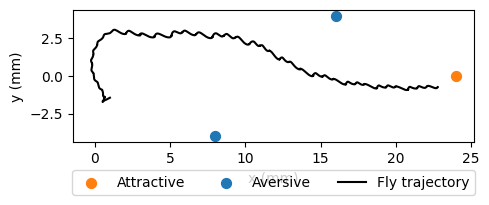

In [7]:
fly_pos_hist = np.array([obs["fly"][0, :2] for obs in obs_hist])

fig, ax = plt.subplots(1, 1, figsize=(5, 4), tight_layout=True)
ax.scatter(
    odor_source[:1, 0],
    odor_source[:1, 1],
    marker="o",
    color="tab:orange",
    s=50,
    label="Attractive",
)
ax.scatter(
    odor_source[1:, 0],
    odor_source[1:, 1],
    marker="o",
    color="tab:blue",
    s=50,
    label="Aversive",
)
ax.plot(fly_pos_hist[:, 0], fly_pos_hist[:, 1], color="k", label="Fly trajectory")
ax.set_aspect("equal")
ax.set_xlabel("x (mm)")
ax.set_ylabel("y (mm)")
ax.legend(ncols=3, loc="lower center", bbox_to_anchor=(0.5, -0.45))
fig.savefig(output_dir / "odor_taxis_trajectory.png")

The full implementation used here lives in `flygym.examples.olfaction.simple_odor_taxis`; it is useful as a compact starting point for changing odor source layouts, changing odor dimensions, or replacing the taxis rule with another controller.